# Clustering Parameter Persistence Analysis

Compute cluster persistence scores across parameter choices to identify robust structures.

**Configuration:** Set options in the first code cell:
- `ALGORITHM`: `"hdbscan"` or `"dbscan"`
- `DATASET`: `"posterior"` (Mode 1 output) or `"control"` (Mode 3 output)

In [10]:
import numpy as np
import h5py
import re
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pymanticore.analysis.matplotlib import get_mplstyle_path

OUTPUT_DIR = Path("../output")
OVERLAP_THRESHOLD = 0.5  # Minimum Jaccard overlap to consider clusters "the same"

# =============================================================================
# CONFIGURATION: Choose algorithm and dataset to analyze
# =============================================================================
# Set to "hdbscan" or "dbscan"
ALGORITHM = "dbscan"  # Options: "hdbscan" or "dbscan"

# Set to "posterior" for Manticore-Local posterior clusters (Mode 1 output)
# Set to "control" for random control clusters (Mode 3 output)
DATASET = "posterior"  # Options: "posterior" or "control"

# Debugging: Load only every Nth parameter run (set to 1 to load all)
LOAD_EVERY_N = 1  # e.g., 2 = load every 2nd file, 3 = every 3rd, etc.

# File patterns for each algorithm and dataset type
# HDBSCAN: parameters are (min_cluster_size, min_samples) - both integers
# DBSCAN: parameters are (eps, min_samples) - eps is float, min_samples is int
FILE_PATTERNS = {
    "hdbscan": {
        "posterior": "hdbscan_clusters_mcs_*_ms_*.h5",
        "control": "hdbscan_random_control_clusters_mcs_*_ms_*.h5"
    },
    "dbscan": {
        "posterior": "dbscan_clusters_eps_*_ms_*.h5",
        "control": "dbscan_random_control_clusters_eps_*_ms_*.h5"
    }
}

# Output filename prefixes
OUTPUT_PREFIXES = {
    "hdbscan": {
        "posterior": "hdbscan_clusters",
        "control": "hdbscan_random_control_clusters"
    },
    "dbscan": {
        "posterior": "dbscan_clusters",
        "control": "dbscan_random_control_clusters"
    }
}

# Parameter names for display
PARAM_NAMES = {
    "hdbscan": ("min_cluster_size", "min_samples"),
    "dbscan": ("eps", "min_samples")
}

# Set plotting style
mnras_style = "mnras"

print(f"Algorithm: {ALGORITHM.upper()}")
print(f"Dataset: {DATASET}")
print(f"File pattern: {FILE_PATTERNS[ALGORITHM][DATASET]}")
print(f"Parameters: {PARAM_NAMES[ALGORITHM]}")
if LOAD_EVERY_N > 1:
    print(f"Debug mode: Loading every {LOAD_EVERY_N}th parameter run")

Algorithm: DBSCAN
Dataset: posterior
File pattern: dbscan_clusters_eps_*_ms_*.h5
Parameters: ('eps', 'min_samples')


## Load All Parameter Runs

In [2]:
def parse_filename(filename, algorithm):
    """Extract parameters from filename based on algorithm type.
    
    HDBSCAN: returns (min_cluster_size, min_samples) as (int, int)
    DBSCAN: returns (eps, min_samples) as (float, int)
    """
    if algorithm == "hdbscan":
        # Pattern: mcs_{int}_ms_{int}
        match = re.search(r'mcs_(\d+)_ms_(\d+)', filename)
        if match:
            return int(match.group(1)), int(match.group(2))
    elif algorithm == "dbscan":
        # Pattern: eps_{float}_ms_{int} (eps can be like 2.5 or 2)
        match = re.search(r'eps_([\d.]+)_ms_(\d+)', filename)
        if match:
            return float(match.group(1)), int(match.group(2))
    return None, None

def load_cluster_members(filepath):
    """Load cluster member indices from HDF5 file.
    
    OPTIMIZED for new flat HDF5 format (v2):
    - Uses /member_index with CSR-style offsets for O(1) member lookup
    - Uses /summary arrays for cluster attributes (bulk read)
    - Falls back to /assignments/label for legacy format (v1)
    
    Uses the global halo index as the unique identifier.
    This is stable across runs since all use the same input data.
    """
    clusters = {}
    
    with h5py.File(filepath, 'r') as f:
        # Check format version
        format_version = f['metadata'].attrs.get('hdf5_format_version', 1)
        
        if format_version >= 2 and 'member_index' in f:
            # NEW FLAT FORMAT (v2) - O(1) member lookup via CSR indexing
            summary = f['summary']
            member_index = f['member_index']
            
            # Bulk read all arrays at once
            cluster_ids = summary['cluster_id'][:]
            existence_probs = summary['existence_prob'][:]
            center_xyzs = summary['center_xyz'][:]
            mean_masses = summary['mean_m200_mass'][:]
            ambiguity_rates = summary['ambiguity_rate'][:]
            offsets = member_index['offsets'][:]
            halo_indices = member_index['halo_indices'][:]
            
            # Build clusters dict - O(C) where C = number of clusters
            for i, cid in enumerate(cluster_ids):
                cid = int(cid)
                start = offsets[i]
                end = offsets[i + 1]
                member_set = set(halo_indices[start:end])
                
                clusters[cid] = {
                    'members': member_set,
                    'n_members': len(member_set),
                    'existence_prob': float(existence_probs[i]),
                    'center_xyz': center_xyzs[i],
                    'mean_m200_mass': float(mean_masses[i]),
                    'ambiguity_rate': float(ambiguity_rates[i])
                }
        else:
            # LEGACY FORMAT (v1) - reconstruct from /assignments/label
            if 'assignments' not in f or 'label' not in f['assignments']:
                print(f"Warning: No assignments found in {filepath}")
                return clusters
            
            # Read labels array once
            labels = f['assignments/label'][:]
            
            # Build cluster -> member indices mapping with single pass - O(N)
            cluster_members = defaultdict(set)
            for idx, label in enumerate(labels):
                if label != -1:
                    cluster_members[label].add(idx)
            
            # Read cluster attributes from /summary arrays (bulk read)
            if 'summary' in f and 'cluster_id' in f['summary']:
                summary = f['summary']
                cluster_ids = summary['cluster_id'][:]
                existence_probs = summary['existence_prob'][:] if 'existence_prob' in summary else np.full(len(cluster_ids), np.nan)
                center_xyzs = summary['center_xyz'][:] if 'center_xyz' in summary else np.full((len(cluster_ids), 3), np.nan)
                mean_masses = summary['mean_m200_mass'][:] if 'mean_m200_mass' in summary else np.full(len(cluster_ids), np.nan)
                ambiguity_rates = summary['ambiguity_rate'][:] if 'ambiguity_rate' in summary else np.full(len(cluster_ids), np.nan)
                
                for i, cid in enumerate(cluster_ids):
                    cid = int(cid)
                    if cid in cluster_members:
                        clusters[cid] = {
                            'members': cluster_members[cid],
                            'n_members': len(cluster_members[cid]),
                            'existence_prob': float(existence_probs[i]),
                            'center_xyz': center_xyzs[i],
                            'mean_m200_mass': float(mean_masses[i]),
                            'ambiguity_rate': float(ambiguity_rates[i])
                        }
            else:
                # Fallback: read from cluster groups (slowest, for very old files)
                if 'clusters' in f:
                    for cluster_name in f['clusters'].keys():
                        cid = int(cluster_name.split('_')[1])
                        if cid in cluster_members:
                            grp = f[f'clusters/{cluster_name}']
                            clusters[cid] = {
                                'members': cluster_members[cid],
                                'n_members': len(cluster_members[cid]),
                                'existence_prob': grp.attrs.get('existence_prob', np.nan),
                                'center_xyz': grp.attrs.get('center_xyz', np.array([np.nan]*3)),
                                'mean_m200_mass': grp.attrs.get('mean_m200_mass', np.nan),
                                'ambiguity_rate': grp.attrs.get('ambiguity_rate', np.nan)
                            }
    
    return clusters

# Find all output files using the configured pattern
file_pattern = FILE_PATTERNS[ALGORITHM][DATASET]
files = sorted(OUTPUT_DIR.glob(file_pattern))
print(f"Found {len(files)} parameter runs for {ALGORITHM.upper()} {DATASET}")

if len(files) == 0:
    raise FileNotFoundError(f"No files matching '{file_pattern}' found in {OUTPUT_DIR}")

# Apply LOAD_EVERY_N filter for debugging
if LOAD_EVERY_N > 1:
    files = files[::LOAD_EVERY_N]
    print(f"Debug mode: Loading {len(files)} files (every {LOAD_EVERY_N}th)")

# Load all runs with progress tracking
all_runs = {}
for f in tqdm(files, desc="Loading parameter runs"):
    param1, param2 = parse_filename(f.name, ALGORITHM)
    if param1 is not None:
        all_runs[(param1, param2)] = load_cluster_members(f)

# Filter out degenerate runs (phase transition regime)
MIN_CLUSTERS = 100  # Runs with fewer clusters are likely degenerate
max_clusters = max(len(c) for c in all_runs.values())

runs = {}
excluded = []
for params, clusters in all_runs.items():
    n_clusters = len(clusters)
    if n_clusters >= MIN_CLUSTERS:
        runs[params] = clusters
    else:
        excluded.append((params, n_clusters))

param1_name, param2_name = PARAM_NAMES[ALGORITHM]
print(f"\nFiltering runs with < {MIN_CLUSTERS} clusters:")
print(f"  Kept: {len(runs)} runs")
print(f"  Excluded: {len(excluded)} degenerate runs")
if excluded:
    print(f"  Excluded params: {[(p, n) for p, n in sorted(excluded)]}")

print(f"\nCluster counts in valid runs:")
for params in sorted(runs.keys()):
    p1_fmt = f"{params[0]:.2f}" if ALGORITHM == "dbscan" else f"{params[0]}"
    print(f"  {param1_name}={p1_fmt}, {param2_name}={params[1]}: {len(runs[params])} clusters")

if len(runs) < 2:
    raise ValueError("Need at least 2 valid parameter runs for persistence analysis")

Found 666 parameter runs for DBSCAN posterior


Loading parameter runs: 100%|██████████| 666/666 [00:56<00:00, 11.70it/s]



Filtering runs with < 100 clusters:
  Kept: 657 runs
  Excluded: 9 degenerate runs
  Excluded params: [((1.0, 14), 83), ((1.0, 15), 74), ((1.0, 16), 65), ((1.0, 17), 53), ((1.0, 18), 50), ((1.0, 19), 45), ((1.0, 20), 44), ((1.25, 19), 94), ((1.25, 20), 85)]

Cluster counts in valid runs:
  eps=1.00, min_samples=3: 3224 clusters
  eps=1.00, min_samples=4: 1454 clusters
  eps=1.00, min_samples=5: 829 clusters
  eps=1.00, min_samples=6: 543 clusters
  eps=1.00, min_samples=7: 393 clusters
  eps=1.00, min_samples=8: 307 clusters
  eps=1.00, min_samples=9: 235 clusters
  eps=1.00, min_samples=10: 183 clusters
  eps=1.00, min_samples=11: 149 clusters
  eps=1.00, min_samples=12: 124 clusters
  eps=1.00, min_samples=13: 101 clusters
  eps=1.25, min_samples=3: 4231 clusters
  eps=1.25, min_samples=4: 1992 clusters
  eps=1.25, min_samples=5: 1186 clusters
  eps=1.25, min_samples=6: 818 clusters
  eps=1.25, min_samples=7: 605 clusters
  eps=1.25, min_samples=8: 473 clusters
  eps=1.25, min_sampl

## Match Clusters Across Runs

In [3]:
# FAST approach: inverted index to avoid unnecessary comparisons
# Key insight: two clusters can only match if they share at least one halo

def build_inverted_index(runs):
    """Build inverted index: halo_id -> list of (params, cluster_id)."""
    index = defaultdict(list)
    cluster_members = {}  # (params, cid) -> set of members
    cluster_sizes = {}    # (params, cid) -> size
    
    for params, clusters in runs.items():
        for cid, cdata in clusters.items():
            members = cdata['members']
            key = (params, cid)
            cluster_members[key] = members
            cluster_sizes[key] = len(members)
            for halo_id in members:
                index[halo_id].append(key)
    
    return index, cluster_members, cluster_sizes

def find_candidates(params, cid, members, inverted_index):
    """Find clusters in OTHER runs that share at least one halo."""
    candidates = defaultdict(set)  # other_params -> set of candidate cids
    for halo_id in members:
        for (other_params, other_cid) in inverted_index[halo_id]:
            if other_params != params:
                candidates[other_params].add(other_cid)
    return candidates

def jaccard_sets(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    intersection = len(set_a & set_b)
    union = len(set_a) + len(set_b) - intersection
    return intersection / union if union > 0 else 0.0

def precompute_all_matches_fast(runs, threshold=OVERLAP_THRESHOLD):
    """Precompute matches using inverted index (much faster)."""
    print("Building inverted index...")
    inverted_index, cluster_members, cluster_sizes = build_inverted_index(runs)
    print(f"  Index size: {len(inverted_index)} unique halos")
    
    matches = {}  # (from_params, to_params) -> {from_cid: (to_cid, jaccard) or None}
    param_list = list(runs.keys())
    
    # Initialize match dictionaries
    for p1 in param_list:
        for p2 in param_list:
            if p1 != p2:
                matches[(p1, p2)] = {}
    
    # Process each run
    total_clusters = sum(len(c) for c in runs.values())
    
    with tqdm(total=total_clusters, desc="Computing matches") as pbar:
        for params, clusters in runs.items():
            for cid, cdata in clusters.items():
                members = cdata['members']
                size_a = len(members)
                
                # Find candidate clusters in other runs
                candidates = find_candidates(params, cid, members, inverted_index)
                
                # For each other run, find best match among candidates
                for other_params in param_list:
                    if other_params == params:
                        continue
                    
                    best_jaccard = 0
                    best_match = None
                    
                    for other_cid in candidates.get(other_params, []):
                        other_members = cluster_members[(other_params, other_cid)]
                        size_b = len(other_members)
                        
                        # Size filter
                        if size_a > 2 * size_b or size_b > 2 * size_a:
                            continue
                        
                        jaccard = jaccard_sets(members, other_members)
                        if jaccard > best_jaccard:
                            best_jaccard = jaccard
                            best_match = other_cid
                    
                    if best_jaccard >= threshold:
                        matches[(params, other_params)][cid] = (best_match, best_jaccard)
                    else:
                        matches[(params, other_params)][cid] = None
                
                pbar.update(1)
    
    return matches

def compute_persistence_from_matches(params, cluster_ids, matches, param_list):
    """Fast persistence lookup using precomputed matches."""
    persistence = {}
    n_runs = len(param_list)
    
    for cid in cluster_ids:
        appearances = 1  # counts itself
        for other_params in param_list:
            if other_params == params:
                continue
            match_result = matches[(params, other_params)].get(cid)
            if match_result is not None:
                appearances += 1
        persistence[cid] = appearances / n_runs
    
    return persistence

# Precompute everything
param_list = list(runs.keys())
print(f"Precomputing matches across {len(param_list)} runs...")
all_matches = precompute_all_matches_fast(runs)
print("\nDone! All subsequent lookups are instant.")

Precomputing matches across 657 runs...
Building inverted index...
  Index size: 318999 unique halos


Computing matches: 100%|██████████| 1598232/1598232 [1:12:57<00:00, 365.14it/s] 



Done! All subsequent lookups are instant.


## Optimal Parameter Recommendation

In [4]:
# For each parameter setting, compute persistence for its own clusters (instant!)
param_scores = {}

for params in tqdm(param_list, desc="Evaluating parameter sets"):
    run_clusters = runs[params]
    persistence = compute_persistence_from_matches(params, run_clusters.keys(), all_matches, param_list)
    
    n_robust = sum(1 for p in persistence.values() if p >= 0.7)
    
    param_scores[params] = {
        'n_clusters': len(run_clusters),
        'n_robust': n_robust,
        'robust_fraction': n_robust / len(run_clusters) if len(run_clusters) > 0 else 0
    }

param1_name, param2_name = PARAM_NAMES[ALGORITHM]
p1_width = 8 if ALGORITHM == "dbscan" else 5  # eps needs more width for floats

print(f"\nParameter Comparison ({ALGORITHM.upper()} {DATASET} dataset):")
print("=" * 70)
print(f"{param1_name:>{p1_width}} {param2_name:>12} {'clusters':>10} {'robust':>10} {'robust_frac':>12}")
print("-" * 70)

for params in sorted(param_scores.keys()):
    s = param_scores[params]
    p1_fmt = f"{params[0]:.2f}" if ALGORITHM == "dbscan" else f"{params[0]}"
    print(f"{p1_fmt:>{p1_width}} {params[1]:>12} {s['n_clusters']:>10} {s['n_robust']:>10} {s['robust_fraction']:>12.1%}")

# Recommend: highest n_robust (absolute count)
best_params = max(param_scores.keys(), 
                  key=lambda p: param_scores[p]['n_robust'])

best_p1_fmt = f"{best_params[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_params[0]}"
print(f"\n** RECOMMENDED for {ALGORITHM.upper()} {DATASET}: {param1_name}={best_p1_fmt}, {param2_name}={best_params[1]} **")
print(f"   {param_scores[best_params]['n_clusters']} clusters, "
      f"{param_scores[best_params]['n_robust']} robust, "
      f"{param_scores[best_params]['robust_fraction']:.1%} robust fraction")

Evaluating parameter sets: 100%|██████████| 657/657 [06:42<00:00,  1.63it/s]


Parameter Comparison (DBSCAN posterior dataset):
     eps  min_samples   clusters     robust  robust_frac
----------------------------------------------------------------------
    1.00            3       3224         86         2.7%
    1.00            4       1454         77         5.3%
    1.00            5        829         66         8.0%
    1.00            6        543         52         9.6%
    1.00            7        393         45        11.5%
    1.00            8        307         40        13.0%
    1.00            9        235         37        15.7%
    1.00           10        183         33        18.0%
    1.00           11        149         32        21.5%
    1.00           12        124         29        23.4%
    1.00           13        101         27        26.7%
    1.25            3       4231        127         3.0%
    1.25            4       1992        118         5.9%
    1.25            5       1186        107         9.0%
    1.25            6   

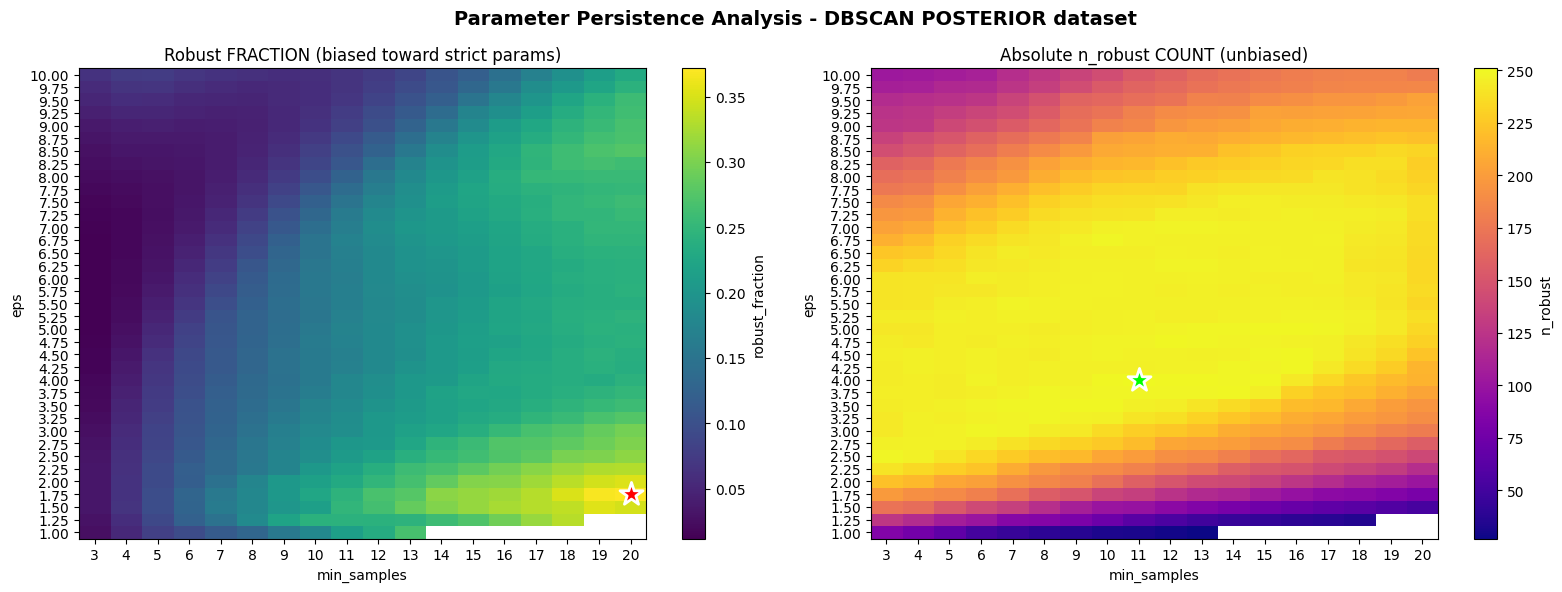


Algorithm: DBSCAN, Dataset: posterior
Best by fraction: eps=1.75, min_samples=20 -> n_robust=81, n_clusters=218
Best by absolute: eps=4.00, min_samples=11 -> n_robust=251, n_clusters=1405


In [5]:
# 2D heatmaps: robust_fraction vs n_robust (absolute)
param1_name, param2_name = PARAM_NAMES[ALGORITHM]
param1_values = sorted(set(p[0] for p in param_scores.keys()))
param2_values = sorted(set(p[1] for p in param_scores.keys()))

# Format tick labels (floats for dbscan eps, ints for hdbscan mcs)
if ALGORITHM == "dbscan":
    param1_labels = [f"{v:.2f}" for v in param1_values]
else:
    param1_labels = [str(v) for v in param1_values]
param2_labels = [str(v) for v in param2_values]

# Build 2D grids
robust_frac_grid = np.full((len(param1_values), len(param2_values)), np.nan)
n_robust_grid = np.full((len(param1_values), len(param2_values)), np.nan)
n_clusters_grid = np.full((len(param1_values), len(param2_values)), np.nan)

for (p1, p2), scores in param_scores.items():
    i = param1_values.index(p1)
    j = param2_values.index(p2)
    robust_frac_grid[i, j] = scores['robust_fraction']
    n_robust_grid[i, j] = scores['n_robust']
    n_clusters_grid[i, j] = scores['n_clusters']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Parameter Persistence Analysis - {ALGORITHM.upper()} {DATASET.upper()} dataset", fontsize=14, fontweight='bold')

# Left: robust_fraction (current metric - biased)
ax = axes[0]
im = ax.imshow(robust_frac_grid, cmap='viridis', aspect='auto', origin='lower')
ax.set_xticks(range(len(param2_values)))
ax.set_xticklabels(param2_labels)
ax.set_yticks(range(len(param1_values)))
ax.set_yticklabels(param1_labels)
ax.set_xlabel(param2_name)
ax.set_ylabel(param1_name)
ax.set_title('Robust FRACTION (biased toward strict params)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('robust_fraction')

# Mark best by fraction
best_frac = max(param_scores.keys(), key=lambda p: param_scores[p]['robust_fraction'])
best_i = param1_values.index(best_frac[0])
best_j = param2_values.index(best_frac[1])
ax.scatter(best_j, best_i, marker='*', s=300, c='red', edgecolors='white', linewidths=2)

# Right: n_robust (absolute count - what you actually want)
ax = axes[1]
im = ax.imshow(n_robust_grid, cmap='plasma', aspect='auto', origin='lower')
ax.set_xticks(range(len(param2_values)))
ax.set_xticklabels(param2_labels)
ax.set_yticks(range(len(param1_values)))
ax.set_yticklabels(param1_labels)
ax.set_xlabel(param2_name)
ax.set_ylabel(param1_name)
ax.set_title('Absolute n_robust COUNT (unbiased)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('n_robust')

# Mark best by absolute count
best_abs = max(param_scores.keys(), key=lambda p: param_scores[p]['n_robust'])
best_i = param1_values.index(best_abs[0])
best_j = param2_values.index(best_abs[1])
ax.scatter(best_j, best_i, marker='*', s=300, c='lime', edgecolors='white', linewidths=2)

plt.tight_layout()
plt.show()

# Format best params for display
best_frac_p1 = f"{best_frac[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_frac[0]}"
best_abs_p1 = f"{best_abs[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_abs[0]}"

print(f"\nAlgorithm: {ALGORITHM.upper()}, Dataset: {DATASET}")
print(f"Best by fraction: {param1_name}={best_frac_p1}, {param2_name}={best_frac[1]} -> "
      f"n_robust={param_scores[best_frac]['n_robust']}, n_clusters={param_scores[best_frac]['n_clusters']}")
print(f"Best by absolute: {param1_name}={best_abs_p1}, {param2_name}={best_abs[1]} -> "
      f"n_robust={param_scores[best_abs]['n_robust']}, n_clusters={param_scores[best_abs]['n_clusters']}")

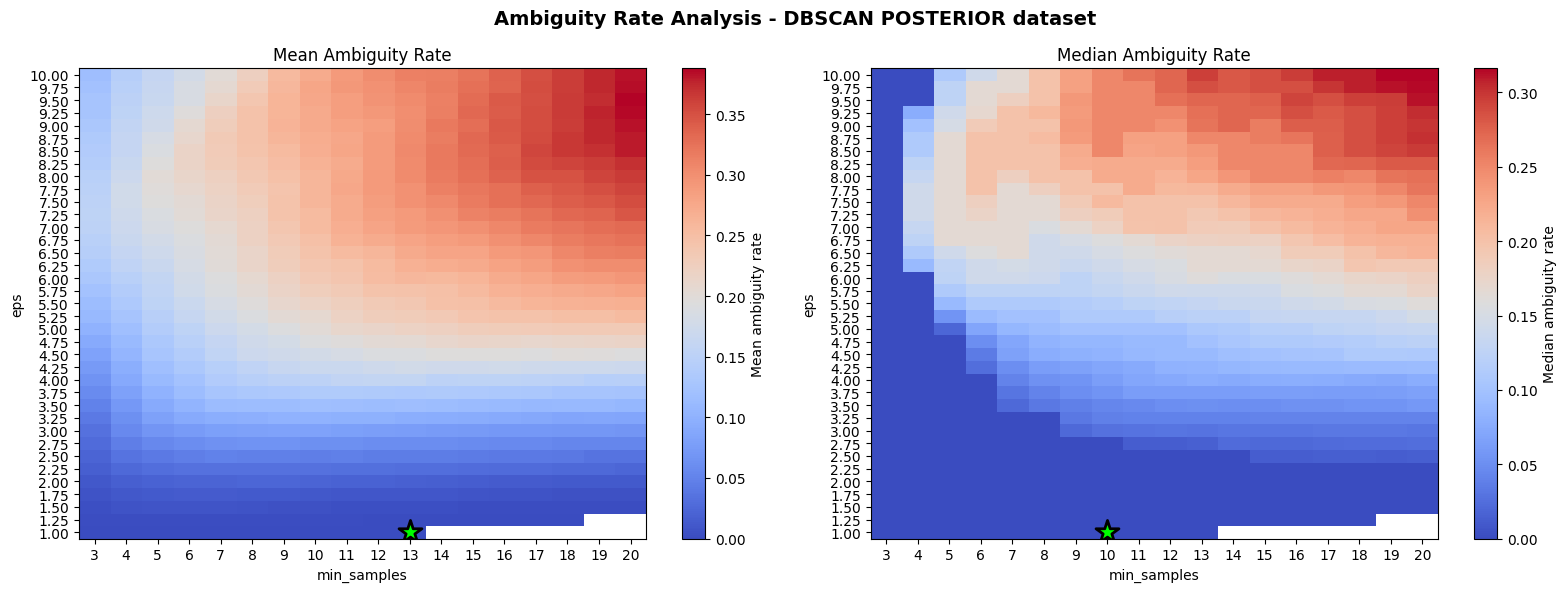


Ambiguity Rate Summary (DBSCAN posterior dataset):
  Lower ambiguity = cleaner cluster assignments (fewer conflicts per realization)
  Lowest mean ambiguity: eps=1.00, min_samples=13 -> 0.000
  Lowest median ambiguity: eps=1.00, min_samples=10 -> 0.000


In [6]:
# Compute mean and median ambiguity rates for each parameter setting
ambiguity_stats = {}

for params, clusters in runs.items():
    ambiguity_rates = [c['ambiguity_rate'] for c in clusters.values() if not np.isnan(c['ambiguity_rate'])]
    if len(ambiguity_rates) > 0:
        ambiguity_stats[params] = {
            'mean': np.mean(ambiguity_rates),
            'median': np.median(ambiguity_rates),
            'n_clusters': len(ambiguity_rates)
        }
    else:
        ambiguity_stats[params] = {
            'mean': np.nan,
            'median': np.nan,
            'n_clusters': 0
        }

# Build 2D grids for ambiguity rates (reuse param1_values, param2_values from cell 8)
mean_ambiguity_grid = np.full((len(param1_values), len(param2_values)), np.nan)
median_ambiguity_grid = np.full((len(param1_values), len(param2_values)), np.nan)

for (p1, p2), stats in ambiguity_stats.items():
    if (p1, p2) in param_scores:  # Only include non-degenerate runs
        i = param1_values.index(p1)
        j = param2_values.index(p2)
        mean_ambiguity_grid[i, j] = stats['mean']
        median_ambiguity_grid[i, j] = stats['median']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Ambiguity Rate Analysis - {ALGORITHM.upper()} {DATASET.upper()} dataset", fontsize=14, fontweight='bold')

# Left: Mean ambiguity rate
ax = axes[0]
im = ax.imshow(mean_ambiguity_grid, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xticks(range(len(param2_values)))
ax.set_xticklabels(param2_labels)
ax.set_yticks(range(len(param1_values)))
ax.set_yticklabels(param1_labels)
ax.set_xlabel(param2_name)
ax.set_ylabel(param1_name)
ax.set_title('Mean Ambiguity Rate')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean ambiguity rate')

# Mark lowest mean ambiguity
valid_mean = {k: v['mean'] for k, v in ambiguity_stats.items() if k in param_scores and not np.isnan(v['mean'])}
if valid_mean:
    best_mean = min(valid_mean.keys(), key=lambda p: valid_mean[p])
    best_i = param1_values.index(best_mean[0])
    best_j = param2_values.index(best_mean[1])
    ax.scatter(best_j, best_i, marker='*', s=300, c='lime', edgecolors='black', linewidths=2)

# Right: Median ambiguity rate
ax = axes[1]
im = ax.imshow(median_ambiguity_grid, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xticks(range(len(param2_values)))
ax.set_xticklabels(param2_labels)
ax.set_yticks(range(len(param1_values)))
ax.set_yticklabels(param1_labels)
ax.set_xlabel(param2_name)
ax.set_ylabel(param1_name)
ax.set_title('Median Ambiguity Rate')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Median ambiguity rate')

# Mark lowest median ambiguity
valid_median = {k: v['median'] for k, v in ambiguity_stats.items() if k in param_scores and not np.isnan(v['median'])}
if valid_median:
    best_median = min(valid_median.keys(), key=lambda p: valid_median[p])
    best_i = param1_values.index(best_median[0])
    best_j = param2_values.index(best_median[1])
    ax.scatter(best_j, best_i, marker='*', s=300, c='lime', edgecolors='black', linewidths=2)

plt.tight_layout()
plt.show()

print(f"\nAmbiguity Rate Summary ({ALGORITHM.upper()} {DATASET} dataset):")
print(f"  Lower ambiguity = cleaner cluster assignments (fewer conflicts per realization)")
if valid_mean:
    best_mean_p1 = f"{best_mean[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_mean[0]}"
    print(f"  Lowest mean ambiguity: {param1_name}={best_mean_p1}, {param2_name}={best_mean[1]} -> {valid_mean[best_mean]:.3f}")
if valid_median:
    best_median_p1 = f"{best_median[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_median[0]}"
    print(f"  Lowest median ambiguity: {param1_name}={best_median_p1}, {param2_name}={best_median[1]} -> {valid_median[best_median]:.3f}")

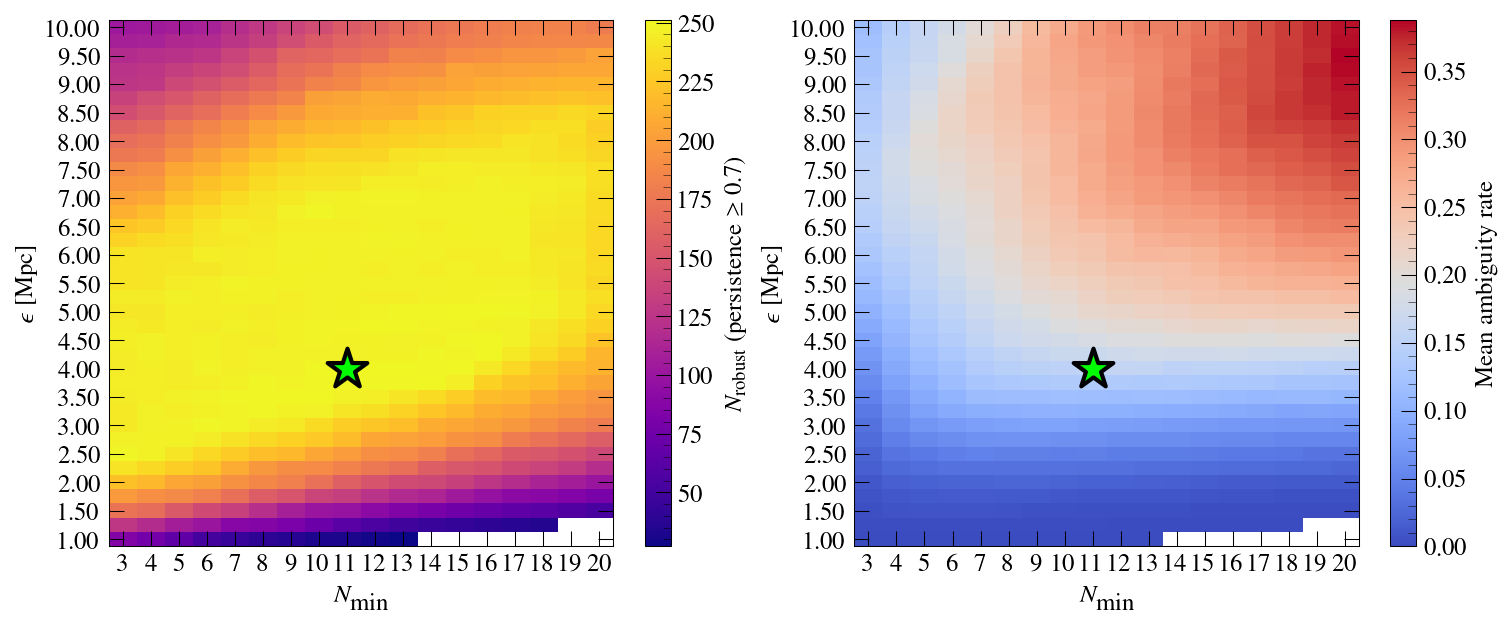


Fiducial parameters (★): eps=4.00, min_samples=11
  Robust clusters: 251
  Total clusters: 1405
  Robust fraction: 17.9%
  Mean ambiguity rate: 0.159


In [25]:
with plt.style.context(get_mplstyle_path(mnras_style)):
    
    # Combined summary plot: n_robust vs mean ambiguity rate
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    # LaTeX-format axis labels where relevant (e.g., eps -> \epsilon)
    param1_name_tex = r'$\epsilon$' if param1_name.strip().lower() in {'eps', 'epsilon', 'ε'} else param1_name
    param2_name_tex = r'$\epsilon$' if param2_name.strip().lower() in {'eps', 'epsilon', 'ε'} else param2_name
    
    # Indices for less-congested y-axis labels (every 2nd value)
    y_idx = list(range(0, len(param1_values), 2))
    y_labels = [param1_labels[i] for i in y_idx]
    
    # Left: Absolute n_robust count
    ax = axes[0]
    im = ax.imshow(n_robust_grid, cmap='plasma', aspect='auto', origin='lower')
    
    ax.set_xticks(range(len(param2_values)))
    ax.set_xticklabels(param2_labels)
    
    ax.set_yticks(y_idx)
    ax.set_yticklabels(y_labels)

    ax.set_xlabel(r"$N_{\textrm{min}}$")
    ax.set_ylabel(r"$\epsilon$ [Mpc]")
    
    # Remove minor ticks explicitly
    ax.minorticks_off()
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(r'$N_{\mathrm{robust}}$ (persistence $\geq$ 0.7)')
    
    # Mark fiducial parameters
    fiducial_i = param1_values.index(best_abs[0])
    fiducial_j = param2_values.index(best_abs[1])
    ax.scatter(
        fiducial_j, fiducial_i,
        marker='*', s=400, c='lime',
        edgecolors='black', linewidths=2, zorder=10
    )
    
    # Right: Mean ambiguity rate
    ax = axes[1]
    im = ax.imshow(mean_ambiguity_grid, cmap='coolwarm', aspect='auto', origin='lower')
    
    ax.set_xticks(range(len(param2_values)))
    ax.set_xticklabels(param2_labels)
    
    ax.set_yticks(y_idx)
    ax.set_yticklabels(y_labels)
    
    ax.set_xlabel(r"$N_{\textrm{min}}$")
    ax.set_ylabel(r"$\epsilon$ [Mpc]")
    
    # Remove minor ticks explicitly
    ax.minorticks_off()
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Mean ambiguity rate')
    
    # Mark fiducial parameters (same location)
    ax.scatter(
        fiducial_j, fiducial_i,
        marker='*', s=400, c='lime',
        edgecolors='black', linewidths=2, zorder=10
    )
    
    plt.tight_layout(pad=0.1)
    plt.savefig("plots/dbscan_heatmaps.pdf")
    plt.show()

# Print fiducial parameter summary
fiducial_p1_fmt = f"{best_abs[0]:.2f}" if ALGORITHM == "dbscan" else f"{best_abs[0]}"
print(f"\nFiducial parameters (★): {param1_name}={fiducial_p1_fmt}, {param2_name}={best_abs[1]}")
print(f"  Robust clusters: {param_scores[best_abs]['n_robust']}")
print(f"  Total clusters: {param_scores[best_abs]['n_clusters']}")
print(f"  Robust fraction: {param_scores[best_abs]['robust_fraction']:.1%}")
if best_abs in ambiguity_stats and not np.isnan(ambiguity_stats[best_abs]['mean']):
    print(f"  Mean ambiguity rate: {ambiguity_stats[best_abs]['mean']:.3f}")

## Export Persistence Scores for Final Catalog

In [21]:
# Choose final parameters based on ABSOLUTE n_robust count (unbiased metric)
# The fraction metric is biased toward stricter params that find fewer clusters
best_by_absolute = max(param_scores.keys(), key=lambda p: param_scores[p]['n_robust'])
FINAL_PARAMS = best_by_absolute  # or set manually, e.g., (16, 12) for HDBSCAN or (2.5, 10) for DBSCAN

# Example manual override:
# FINAL_PARAMS = (16, 13)  # HDBSCAN: (min_cluster_size, min_samples)
# FINAL_PARAMS = (2.5, 10)  # DBSCAN: (eps, min_samples)

final_clusters = runs[FINAL_PARAMS]

print(f"Computing persistence for final {ALGORITHM.upper()} {DATASET} catalog (instant lookup)...")
final_persistence = compute_persistence_from_matches(
    FINAL_PARAMS, final_clusters.keys(), all_matches, param_list
)

# Format parameters for display
param1_name, param2_name = PARAM_NAMES[ALGORITHM]
final_p1_fmt = f"{FINAL_PARAMS[0]:.2f}" if ALGORITHM == "dbscan" else f"{FINAL_PARAMS[0]}"

print(f"\nFinal {ALGORITHM.upper()} {DATASET} catalog: {param1_name}={final_p1_fmt}, {param2_name}={FINAL_PARAMS[1]}")
print(f"Clusters with persistence scores: {len(final_persistence)}")

# Summary
persistence_vals = np.array(list(final_persistence.values()))
print(f"\nPersistence distribution:")
print(f"  Perfect (1.0): {np.sum(persistence_vals == 1.0)}")
print(f"  Robust (>=0.7): {np.sum(persistence_vals >= 0.7)}")
print(f"  Moderate (0.5-0.7): {np.sum((persistence_vals >= 0.5) & (persistence_vals < 0.7))}")
print(f"  Fragile (<0.5): {np.sum(persistence_vals < 0.5)}")

print(f"\nTop 10 most robust clusters:")
for cid in sorted(final_persistence.keys(), key=lambda x: -final_persistence[x])[:10]:
    cdata = final_clusters[cid]
    print(f"  Cluster {cid}: persistence={final_persistence[cid]:.2f}, "
          f"exist_prob={cdata['existence_prob']:.2f}, mass={cdata['mean_m200_mass']:.2e}")

Computing persistence for final DBSCAN posterior catalog (instant lookup)...

Final DBSCAN posterior catalog: eps=4.00, min_samples=11
Clusters with persistence scores: 1405

Persistence distribution:
  Perfect (1.0): 12
  Robust (>=0.7): 251
  Moderate (0.5-0.7): 227
  Fragile (<0.5): 927

Top 10 most robust clusters:
  Cluster 33: persistence=1.00, exist_prob=1.00, mass=1.78e+14
  Cluster 44: persistence=1.00, exist_prob=1.00, mass=3.24e+14
  Cluster 51: persistence=1.00, exist_prob=1.00, mass=3.89e+14
  Cluster 53: persistence=1.00, exist_prob=1.00, mass=3.22e+14
  Cluster 61: persistence=1.00, exist_prob=1.00, mass=1.48e+14
  Cluster 76: persistence=1.00, exist_prob=1.00, mass=2.46e+14
  Cluster 85: persistence=1.00, exist_prob=1.00, mass=2.37e+14
  Cluster 115: persistence=1.00, exist_prob=0.99, mass=1.73e+14
  Cluster 137: persistence=1.00, exist_prob=0.97, mass=2.04e+14
  Cluster 198: persistence=1.00, exist_prob=0.93, mass=1.39e+14


In [22]:
# Save persistence scores to the final HDF5 file
output_prefix = OUTPUT_PREFIXES[ALGORITHM][DATASET]

# Build filename based on algorithm
if ALGORITHM == "hdbscan":
    final_file = OUTPUT_DIR / f"{output_prefix}_mcs_{FINAL_PARAMS[0]}_ms_{FINAL_PARAMS[1]}.h5"
else:  # dbscan
    final_file = OUTPUT_DIR / f"{output_prefix}_eps_{FINAL_PARAMS[0]}_ms_{FINAL_PARAMS[1]}.h5"

print(f"Saving to: {final_file}")

with h5py.File(final_file, 'r+') as f:
    # Check format version
    format_version = f['metadata'].attrs.get('hdf5_format_version', 1)
    
    if format_version >= 2:
        # NEW FLAT FORMAT (v2) - save as array in /summary
        summary = f['summary']
        cluster_ids = summary['cluster_id'][:]
        
        # Build persistence array aligned with cluster_ids
        persistence_array = np.full(len(cluster_ids), np.nan)
        for i, cid in enumerate(cluster_ids):
            cid = int(cid)
            if cid in final_persistence:
                persistence_array[i] = final_persistence[cid]
        
        # Delete old dataset if exists, then create new
        if 'persistence_score' in summary:
            del summary['persistence_score']
        summary.create_dataset('persistence_score', data=persistence_array)
        
    else:
        # LEGACY FORMAT (v1) - save as attribute per cluster
        for cid, persistence in final_persistence.items():
            cluster_path = f'clusters/cluster_{cid}'
            if cluster_path in f:
                f[cluster_path].attrs['persistence_score'] = persistence
    
    # Add persistence metadata
    if 'persistence_analysis' in f:
        del f['persistence_analysis']
    pa = f.create_group('persistence_analysis')
    pa.attrs['n_parameter_runs'] = len(runs)
    pa.attrs['parameter_grid'] = str(list(runs.keys()))
    pa.attrs['overlap_threshold'] = OVERLAP_THRESHOLD
    pa.attrs['final_params'] = str(FINAL_PARAMS)
    pa.attrs['dataset_type'] = DATASET
    pa.attrs['algorithm'] = ALGORITHM

print(f"Saved persistence scores to {final_file}")

Saving to: ../output/dbscan_clusters_eps_4.0_ms_11.h5
Saved persistence scores to ../output/dbscan_clusters_eps_4.0_ms_11.h5
